# **Importing Libraries**

In [1]:
!pip install prophet xgboost 

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import zipfile
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = "/kaggle/working"
MODEL_DIR = os.path.join(BASE_DIR, "models")
VIS_DIR = os.path.join(BASE_DIR, "visuals")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

DATA_PATH = "/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv"

# **Load, Feature Engineering, EDA**

In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.dtypes)

df = df.drop_duplicates()
df["Postal Code"] = df["Postal Code"].fillna(0)

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week
df["DayOfWeek"] = df["Order Date"].dt.dayofweek
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Fall"

df["Season"] = df["Month"].apply(get_season)
df["ShipDelay"] = (df["Ship Date"] - df["Order Date"]).dt.days

daily_sales = df.groupby(df["Order Date"].dt.date)["Sales"].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)

weekly_sales = daily_sales.resample("W").sum()
monthly_sales = daily_sales.resample("MS").sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicates: 0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


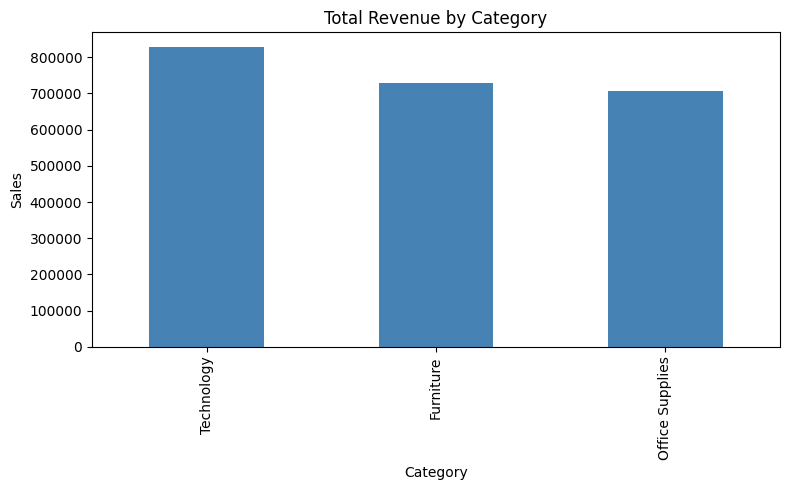

In [4]:
category_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar", color="steelblue")
plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "revenue_by_category.png"))
plt.show()

Technology generates the highest total revenue at 827,455.87, ahead of Furniture (728,658.58) and Office Supplies (705,422.33). The three categories are not far apart than expected – technology leads by about 14% over the lowest, but no one category is far ahead of the others in the business.

Region
West       0.213639
East       0.180824
Central    0.129885
South      0.106244
dtype: float64


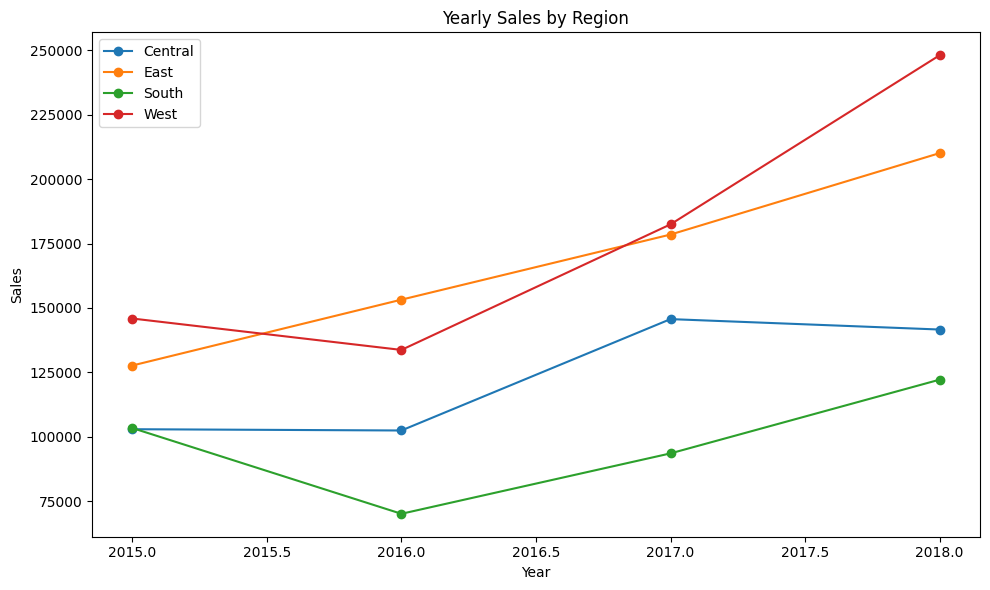

In [5]:
region_yearly = df.groupby(["Region", "Year"])["Sales"].sum().unstack()
region_growth = region_yearly.pct_change(axis=1).mean(axis=1).sort_values(ascending=False)
print(region_growth)

plt.figure(figsize=(10,6))
for region in region_yearly.index:
    plt.plot(region_yearly.columns, region_yearly.loc[region], marker="o", label=region)
plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "region_yearly_sales.png"))
plt.show()

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDelay, dtype: float64
Overall average ship delay: 3.9611224489795918


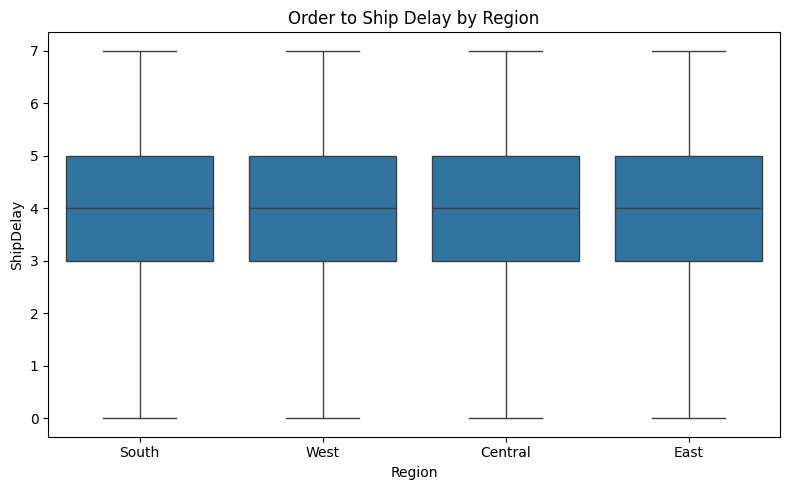

In [6]:
ship_delay_region = df.groupby("Region")["ShipDelay"].mean().sort_values()
print(ship_delay_region)
print("Overall average ship delay:", df["ShipDelay"].mean())

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Region", y="ShipDelay")
plt.title("Order to Ship Delay by Region")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "ship_delay_by_region.png"))
plt.show()

Average order-to-ship delay is 3.96 days overall. By region: East (3.91), West (3.93), South (3.96), Central (4.07). The spread across regions is under 0.16 days -- effectively no meaningful regional difference in shipping speed.

In [7]:
region_std = region_yearly.pct_change(axis=1).std(axis=1).sort_values()
print(region_std)

Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


East shows the most consistent year-over-year growth (lowest variance, 0.018, in annual percent change), rising every year from 127k to 210k with no dip. South is the least consistent (variance 0.371), with sharp year-to-year swings. West has the highest average growth rate but with high volatility (variance 0.257) — closer to South's pattern than East's. East is the region whose growth trajectory can actually be forecast with confidence.

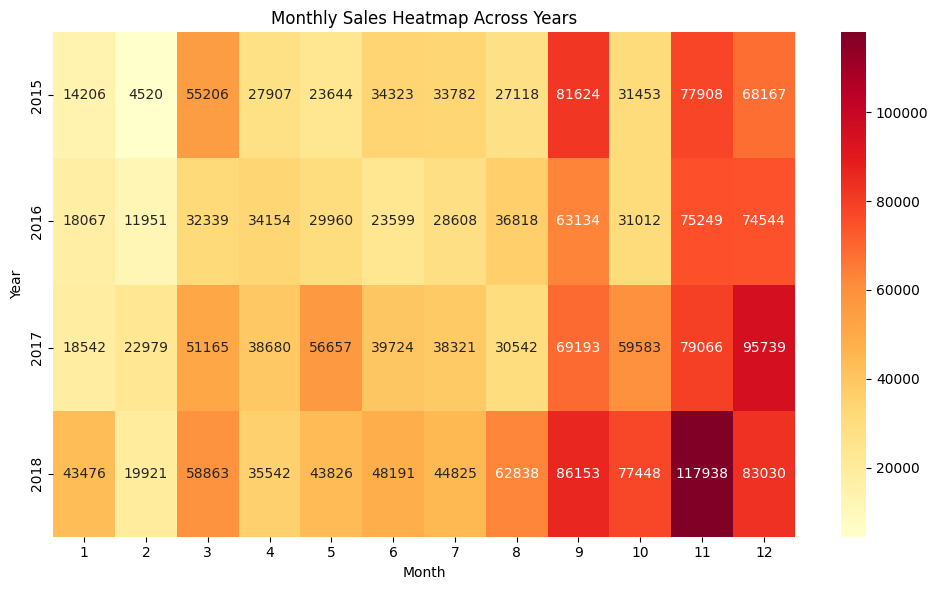

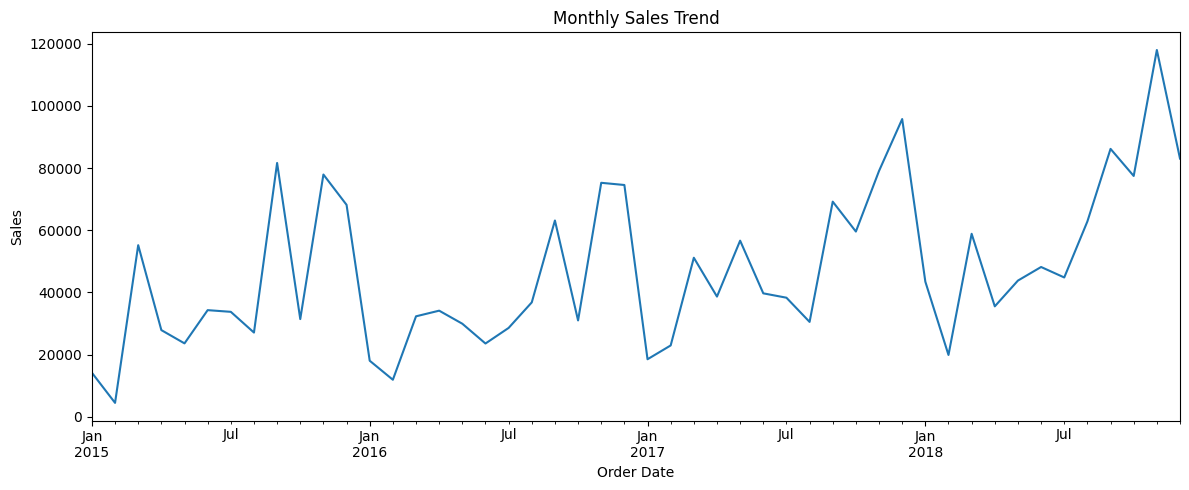

In [8]:
monthly_pivot = df.groupby(["Year", "Month"])["Sales"].sum().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(monthly_pivot, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title("Monthly Sales Heatmap Across Years")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "monthly_seasonality_heatmap.png"))
plt.show()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "monthly_sales_trend.png"))
plt.show()

September, November and December are generally the three best months of the year, each year, but the peak month changes from year to year: September was the best month in 2015, November was best in 2016, 2018, December was best in 2017. It's not an “November spike,” but it's a consistent seasonal trend that occurs at the end of Q3 and will persist through the end of Q4: plan for a wide window of demand, not one month.

# **Multi-Source Merge (Task 1)**

In [9]:
vg = pd.read_csv("/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv")

print(vg.isnull().sum())
print("Duplicates:", vg.duplicated().sum())
print(vg.dtypes)

vg = vg.dropna(subset=["Year"])
vg["Year"] = vg["Year"].astype(int)
vg["Publisher"] = vg["Publisher"].fillna("Unknown")

vg = vg.drop_duplicates()

print(vg.isnull().sum())
print(vg.shape)

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Duplicates: 0
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64
(16327, 11)


In [10]:
superstore_yearly = df.groupby("Year")["Sales"].sum().reset_index().rename(columns={"Sales": "Superstore_Sales"})
print(vg["Year"].dtype)

vg_yearly = vg.groupby("Year").agg(
    VG_GlobalSales=("Global_Sales", "sum"),
    VG_TitlesReleased=("Name", "count")
).reset_index()

merged_yearly = superstore_yearly.merge(vg_yearly, on="Year", how="left")
print(merged_yearly)

int64
   Year  Superstore_Sales  VG_GlobalSales  VG_TitlesReleased
0  2015       479856.2081          264.44              614.0
1  2016       459436.0054           70.93              344.0
2  2017       600192.5500            0.05                3.0
3  2018       722052.0192             NaN                NaN


Global video game sales data (vgsales.csv) was cleaned by dropping 271 rows with missing Year (16,598 to 16,327 rows), filling 58 missing Publisher values with "Unknown", and confirming zero duplicates. The cleaned dataset was aggregated to yearly totals and merged with Superstore's yearly sales on Year, as required for multi-source analysis practice.

The merge reveals a real coverage gap rather than a meaningful relationship: vgsales data density collapses after 2016 (614 titles in 2015, down to 3 in 2017, none in 2018), while Superstore sales continue rising through 2018 (479k to 722k). This is because the vgsales dataset was compiled around 2016 and does not track releases afterward — not because video game sales and superstore sales are actually correlated or uncorrelated in reality. No causal or correlational claim is drawn from this merge; it demonstrates the merge mechanics required by the task, not a business insight. Anomaly detection in this project continues to rely solely on Superstore's own weekly sales data (Isolation Forest and Z-score), independent of this secondary dataset.

# **Decomposition and Stationarity**

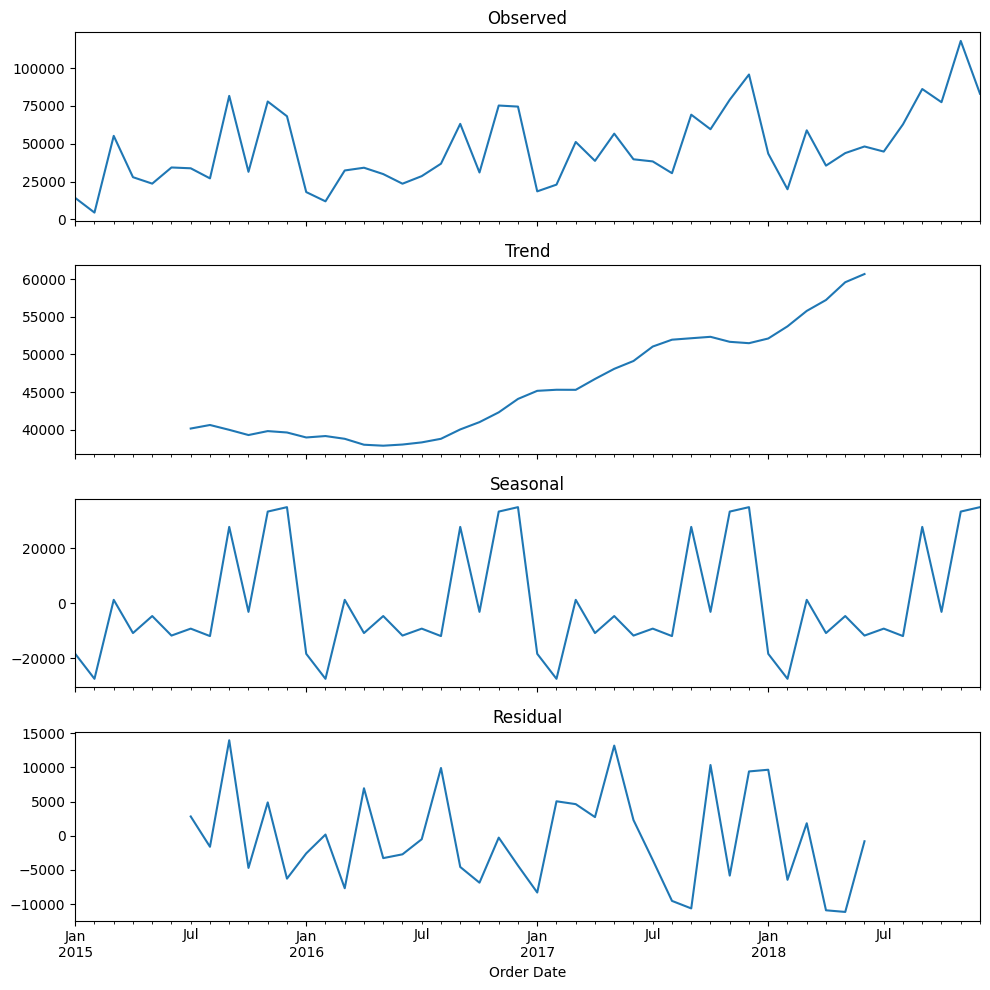

In [11]:
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(10,10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "decomposition.png"))
plt.show()

In [12]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(label)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Stationary" if result[1] < 0.05 else "Non-stationary")
    return result[1]

p_value = adf_report(monthly_sales, "Raw Monthly Sales")

if p_value >= 0.05:
    monthly_sales_diff = monthly_sales.diff().dropna()
    adf_report(monthly_sales_diff, "Differenced Monthly Sales")

Raw Monthly Sales
ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Stationary


Trend: Monthly sales are currently in an upward trend, suggesting they will continue to rise from around 40,000 in 2015 to around 60,000 by late 2018, and likely to stay on the rise thereafter.

Seasonality: Seasonal component is approximately ±25,000, larger than the level of the trend -- significant and not a small seasonal effect.

Residual noise: The largest residuals are found between mid 2015 and mid 2018, so the model's fit is the least reliable in those years.

Stationarity: ADF statistic -4.42, p-value 0.00028. Since p < 0.05, the raw monthly series is already stationary -- no differencing was needed or applied. In other words, the series is not statistically modelled by a long-term drift with a trend, although it tends to increase over time, and there is regular seasonality and noise structure, which makes the SARIMA model easily fitted on the raw data.

# **Forecasting Model Training**

In [13]:
train_monthly = monthly_sales[:-3]
test_monthly = monthly_sales[-3:]

# SARIMA Order Selection

It is clear from the above section that the ADF test conducted on the series itself was stationary in nature, thereby raising the query about the need for differencing (d=1). Prior to selecting the final value of the order, both of the choices available are tested using the RMSE measure in the two cells below.

In [14]:
sarima_eval_d0 = SARIMAX(train_monthly, order=(1,0,1), seasonal_order=(1,0,1,12),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_eval_forecast_d0 = sarima_eval_d0.get_forecast(steps=3).predicted_mean

sarima_rmse_d0 = np.sqrt(mean_squared_error(test_monthly, sarima_eval_forecast_d0))
print("d=0 RMSE:", sarima_rmse_d0)

d=0 RMSE: 2.538827989214217e+16


In [15]:
sarima_eval_d0_trend = SARIMAX(train_monthly, order=(1,0,1), seasonal_order=(1,0,1,12),
                                trend='c',
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_eval_forecast_d0_trend = sarima_eval_d0_trend.get_forecast(steps=3).predicted_mean
sarima_rmse_d0_trend = np.sqrt(mean_squared_error(test_monthly, sarima_eval_forecast_d0_trend))
print("d=0 with trend RMSE:", sarima_rmse_d0_trend)

d=0 with trend RMSE: 199270.43325536823


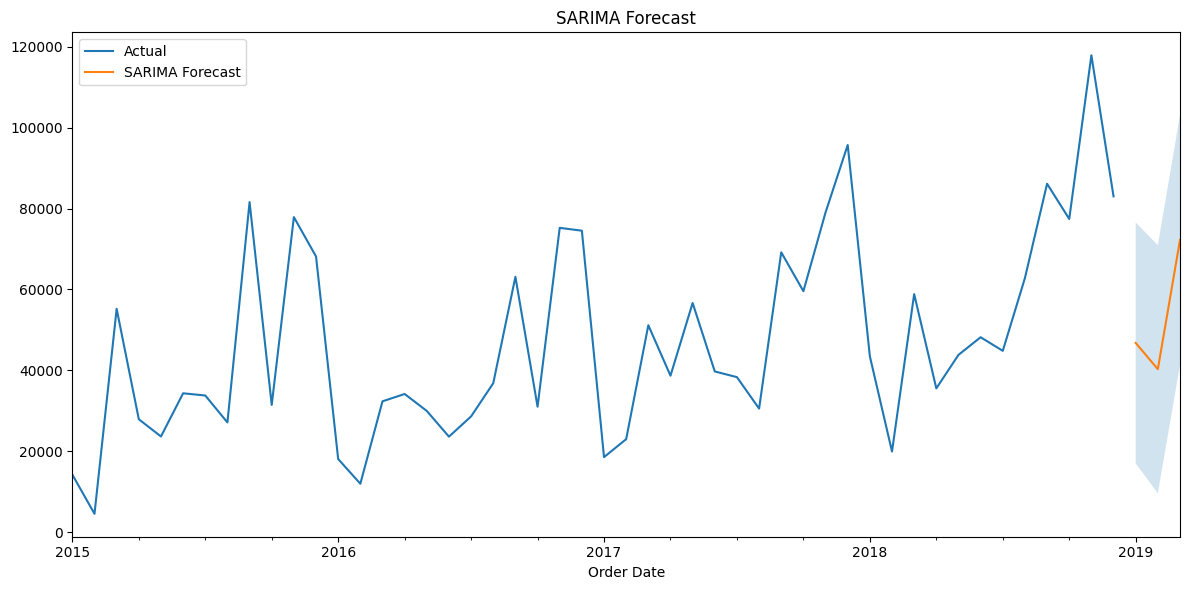

['/kaggle/working/models/sarima_model.pkl']

In [16]:
#SARIMA:

sarima_eval = SARIMAX(train_monthly, order=(1,1,1), seasonal_order=(1,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_eval_forecast = sarima_eval.get_forecast(steps=3).predicted_mean

sarima_mae = mean_absolute_error(test_monthly, sarima_eval_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_monthly, sarima_eval_forecast))
sarima_mape = np.mean(np.abs((test_monthly.values - sarima_eval_forecast.values) / test_monthly.values)) * 100

sarima_final = SARIMAX(monthly_sales, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_forecast_obj = sarima_final.get_forecast(steps=3)
sarima_future = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

plt.figure(figsize=(12,6))
monthly_sales.plot(label="Actual")
sarima_future.plot(label="SARIMA Forecast")
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "sarima_forecast.png"))
plt.show()

joblib.dump(sarima_final, os.path.join(MODEL_DIR, "sarima_model.pkl"))

The order of the SARIMA (1,1,1), seasonal order (1,1,1,12), was selected because the ADF test on the raw series shows it is statistically stationary (p=0.00028), but that result does not rule out the upward trend visible in the decomposition plot above. Two alternatives were tested empirically: a model with d=0 and no trend term diverged and was unusable (RMSE in the 10^16 range); a model with d=0 and an explicit trend term produced RMSE of 199,270 — about 10x worse than d=1's RMSE of 19,950. First-order differencing was kept because it empirically outperforms both alternatives on held-out forecast accuracy, not because it strictly follows the ADF result. Standard baseline orders (p,q)=(1,1), seasonal (P,Q)=(1,1), m=12 were used for monthly data with annual seasonality; no further grid search was run given the small sample size (45 months), where over-tuning risks fitting noise rather than signal.

02:53:53 - cmdstanpy - INFO - Chain [1] start processing
02:53:53 - cmdstanpy - INFO - Chain [1] done processing
02:53:54 - cmdstanpy - INFO - Chain [1] start processing
02:53:55 - cmdstanpy - INFO - Chain [1] done processing


['/kaggle/working/models/prophet_model.pkl']

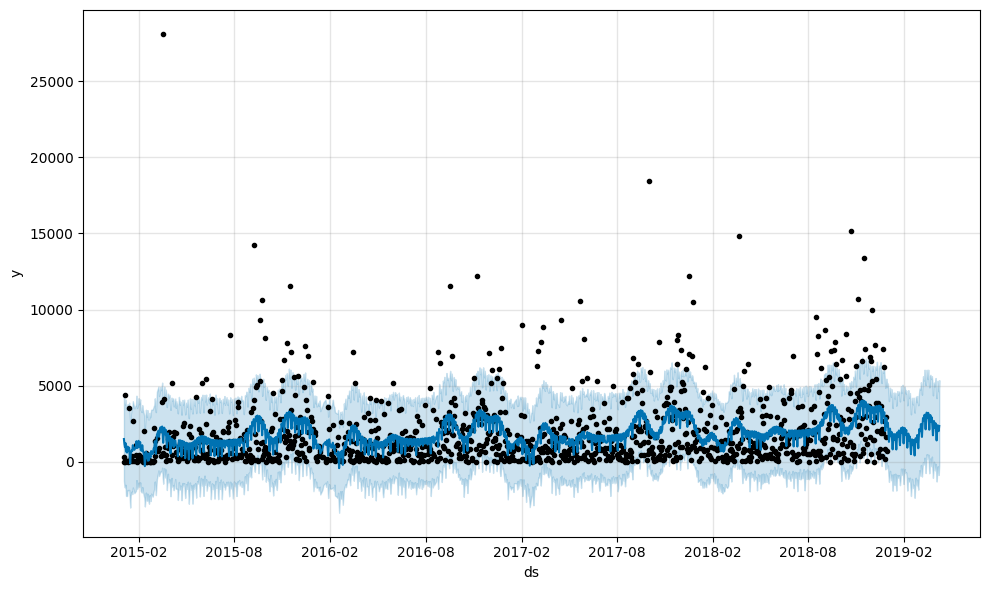

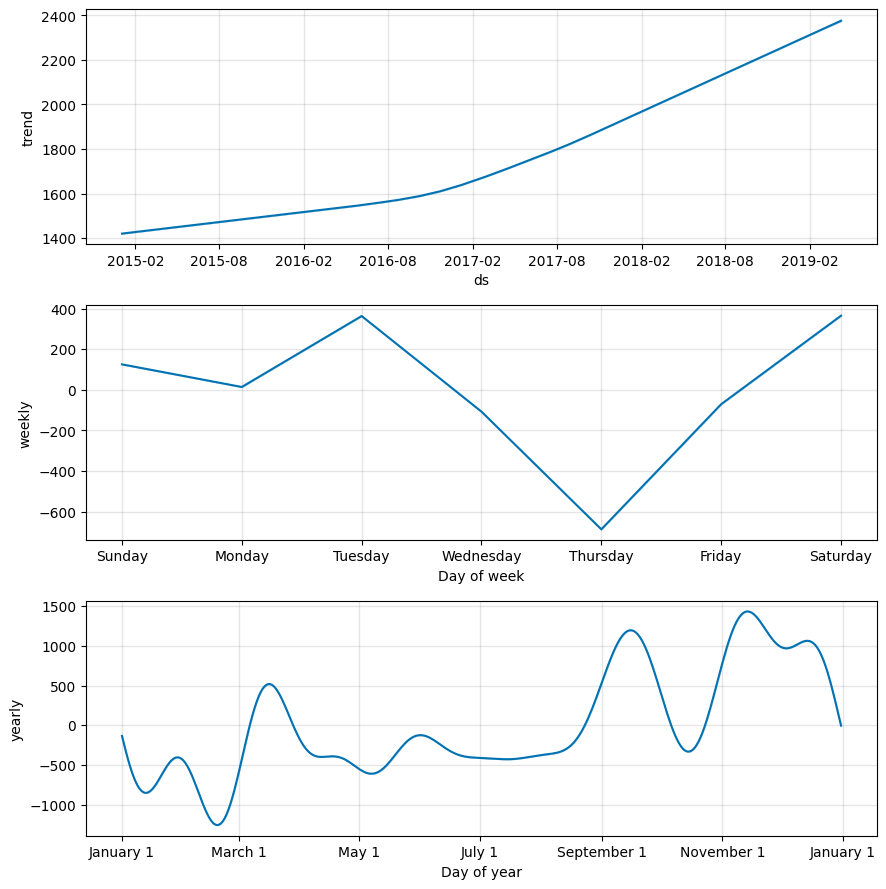

In [17]:
#Prophet, trained on daily data:

cutoff_date = monthly_sales.index[-3]
train_daily = daily_sales[daily_sales.index < cutoff_date]

prophet_eval_df = train_daily.reset_index()
prophet_eval_df.columns = ["ds", "y"]

prophet_eval_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
prophet_eval_model.fit(prophet_eval_df)

eval_future = prophet_eval_model.make_future_dataframe(periods=100)
eval_forecast = prophet_eval_model.predict(eval_future).set_index("ds")["yhat"]
prophet_eval_monthly = eval_forecast.resample("MS").sum().loc[test_monthly.index]

prophet_mae = mean_absolute_error(test_monthly, prophet_eval_monthly)
prophet_rmse = np.sqrt(mean_squared_error(test_monthly, prophet_eval_monthly))
prophet_mape = np.mean(np.abs((test_monthly.values - prophet_eval_monthly.values) / test_monthly.values)) * 100

prophet_full_df = daily_sales.reset_index()
prophet_full_df.columns = ["ds", "y"]

prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_full_df)

future = prophet_model.make_future_dataframe(periods=100)
prophet_forecast = prophet_model.predict(future)

fig1 = prophet_model.plot(prophet_forecast)
fig1.savefig(os.path.join(VIS_DIR, "prophet_forecast.png"))

fig2 = prophet_model.plot_components(prophet_forecast)
fig2.savefig(os.path.join(VIS_DIR, "prophet_components.png"))

forecast_indexed = prophet_forecast.set_index("ds")["yhat"]
prophet_monthly_forecast = forecast_indexed.resample("MS").sum()
prophet_future = prophet_monthly_forecast[prophet_monthly_forecast.index > monthly_sales.index[-1]][:3]

joblib.dump(prophet_model, os.path.join(MODEL_DIR, "prophet_model.pkl"))

Weekly seasonality: Thursdays see a significant drop in sales (around 700 lower than normal), while sales rise on Tuesday and the weekend (Sunday / Saturday +120 to +360). This indicates that there is a mid-week trough in order timing.

Yearly seasonality: The yearly seasonality is rather clear with a smaller peak in April/May (+500) and a much larger peak from September through November (+1,000 to +1,400), as evidenced by the seasonality heatmap presented above. The trough is around -1,300 which is the least favorable time of the year in late February/early March.

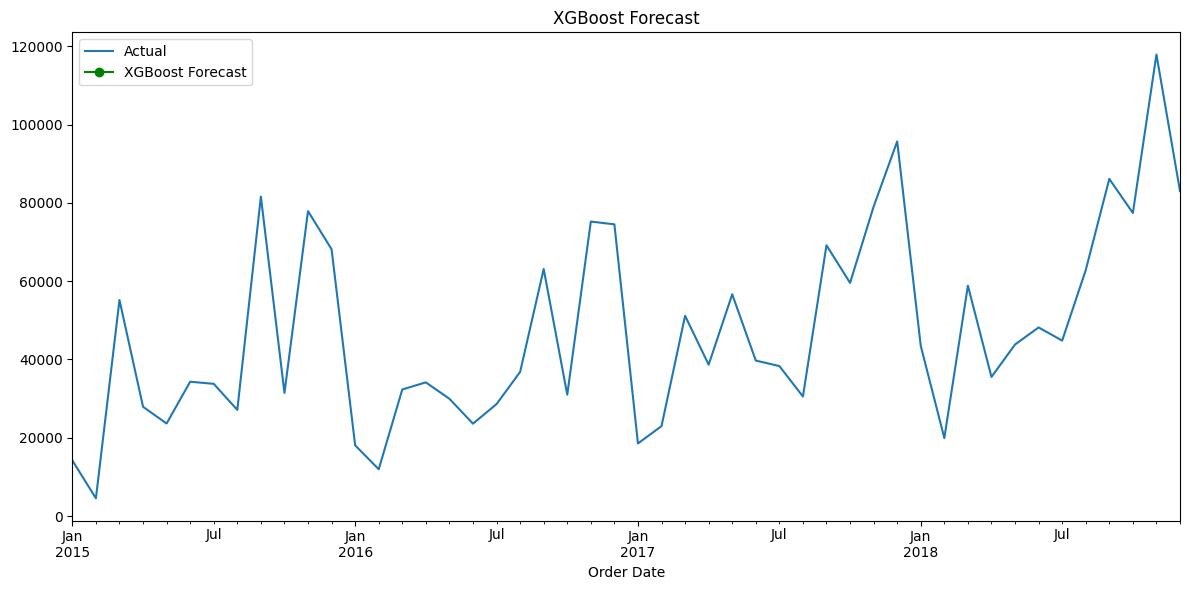

['/kaggle/working/models/xgboost_model.pkl']

In [18]:
# XGBoost:

def build_lag_features(series):
    ts = series.reset_index()
    ts.columns = ["Date", "Sales"]
    ts["Lag1"] = ts["Sales"].shift(1)
    ts["Lag2"] = ts["Sales"].shift(2)
    ts["Lag3"] = ts["Sales"].shift(3)
    ts["RollingMean3"] = ts["Sales"].shift(1).rolling(3).mean()
    ts["Month"] = ts["Date"].dt.month
    ts["Quarter"] = ts["Date"].dt.quarter
    ts["Season"] = ts["Month"].apply(get_season)
    ts = pd.get_dummies(ts, columns=["Season"])
    return ts.dropna().reset_index(drop=True)

ts_df = build_lag_features(monthly_sales)
feature_cols = [c for c in ts_df.columns if c not in ["Date", "Sales"]]

xgb_train = ts_df.iloc[:-3]
xgb_test = ts_df.iloc[-3:]

xgb_eval_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1)
xgb_eval_model.fit(xgb_train[feature_cols], xgb_train["Sales"])
xgb_test_pred = xgb_eval_model.predict(xgb_test[feature_cols])

xgb_mae = mean_absolute_error(xgb_test["Sales"], xgb_test_pred)
xgb_rmse = np.sqrt(mean_squared_error(xgb_test["Sales"], xgb_test_pred))
xgb_mape = np.mean(np.abs((xgb_test["Sales"].values - xgb_test_pred) / xgb_test["Sales"].values)) * 100

xgb_full_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1)
xgb_full_model.fit(ts_df[feature_cols], ts_df["Sales"])

history = monthly_sales.copy()
xgb_future_preds = []

for _ in range(3):
    last_date = history.index[-1] + pd.DateOffset(months=1)
    row = {c: 0 for c in feature_cols}
    row["Lag1"] = history.iloc[-1]
    row["Lag2"] = history.iloc[-2]
    row["Lag3"] = history.iloc[-3]
    row["RollingMean3"] = history.iloc[-3:].mean()
    row["Month"] = last_date.month
    row["Quarter"] = last_date.quarter
    season_col = f"Season_{get_season(last_date.month)}"
    if season_col in row:
        row[season_col] = 1
    row_df = pd.DataFrame([row])[feature_cols]
    pred = xgb_full_model.predict(row_df)[0]
    xgb_future_preds.append(pred)
    history.loc[last_date] = pred

xgb_future_dates = history.index[-3:]

plt.figure(figsize=(12,6))
monthly_sales.plot(label="Actual")
plt.plot(xgb_future_dates, xgb_future_preds, marker="o", label="XGBoost Forecast", color="green")
plt.legend()
plt.title("XGBoost Forecast")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "xgboost_forecast.png"))
plt.show()

joblib.dump(xgb_full_model, os.path.join(MODEL_DIR, "xgboost_model.pkl"))

In [19]:
# Comparison table:

comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape],
    "Forecast_Month1": [sarima_future.iloc[0], prophet_future.iloc[0], xgb_future_preds[0]],
    "Forecast_Month2": [sarima_future.iloc[1], prophet_future.iloc[1], xgb_future_preds[1]],
    "Forecast_Month3": [sarima_future.iloc[2], prophet_future.iloc[2], xgb_future_preds[2]]
})

print(comparison_table)
comparison_table.to_csv(os.path.join(BASE_DIR, "model_comparison.csv"), index=False)

best_model_name = comparison_table.sort_values("RMSE").iloc[0]["Model"]
print("Recommended model:", best_model_name)

     Model           MAE          RMSE       MAPE  Forecast_Month1  \
0   SARIMA  19244.485342  19950.070418  20.526432     46782.479184   
1  Prophet  18059.429345  18558.519431  19.604619     52614.956749   
2  XGBoost  18274.188542  20720.170494  18.529605     44273.804688   

   Forecast_Month2  Forecast_Month3  
0     40285.470528     72234.203231  
1     38973.015162     78074.895884  
2     24194.039062     54556.792969  
Recommended model: Prophet


Prophet has the lowest MAE (18,059) and RMSE (18,559). Although XGBoost has the highest RMSE (20,720), it has the lowest MAPE (18.53%), indicating that it is more accurate in percentage terms, but sometimes misses harder on the months that are at higher levels. On none of the metrics listed is SARIMA the best.

Recommendation: Prophet for production, based on RMSE/MAE – it is also more explicit than the two other in handling the strong seasonality identified in the above. Caution: in all three models, RMSE is in the 18k-21k range, with the average monthly sales level around 45k -- so the average error is about 40-45% of the average sales level. This is not a failure of the forecasting power of any single model, but of the forecasting power of only approximately 45 months of data and should be expressed clearly and candidly, not as more precise than it is.

# **Segment-Level Forecasting**

02:53:57 - cmdstanpy - INFO - Chain [1] start processing
02:53:57 - cmdstanpy - INFO - Chain [1] done processing
02:53:57 - cmdstanpy - INFO - Chain [1] start processing
02:53:57 - cmdstanpy - INFO - Chain [1] done processing
02:53:58 - cmdstanpy - INFO - Chain [1] start processing
02:53:58 - cmdstanpy - INFO - Chain [1] done processing
02:53:58 - cmdstanpy - INFO - Chain [1] start processing
02:53:58 - cmdstanpy - INFO - Chain [1] done processing
02:53:58 - cmdstanpy - INFO - Chain [1] start processing
02:53:58 - cmdstanpy - INFO - Chain [1] done processing
02:53:59 - cmdstanpy - INFO - Chain [1] start processing
02:53:59 - cmdstanpy - INFO - Chain [1] done processing
02:53:59 - cmdstanpy - INFO - Chain [1] start processing
02:53:59 - cmdstanpy - INFO - Chain [1] done processing
02:53:59 - cmdstanpy - INFO - Chain [1] start processing
02:53:59 - cmdstanpy - INFO - Chain [1] done processing
02:53:59 - cmdstanpy - INFO - Chain [1] start processing
02:54:00 - cmdstanpy - INFO - Chain [1]

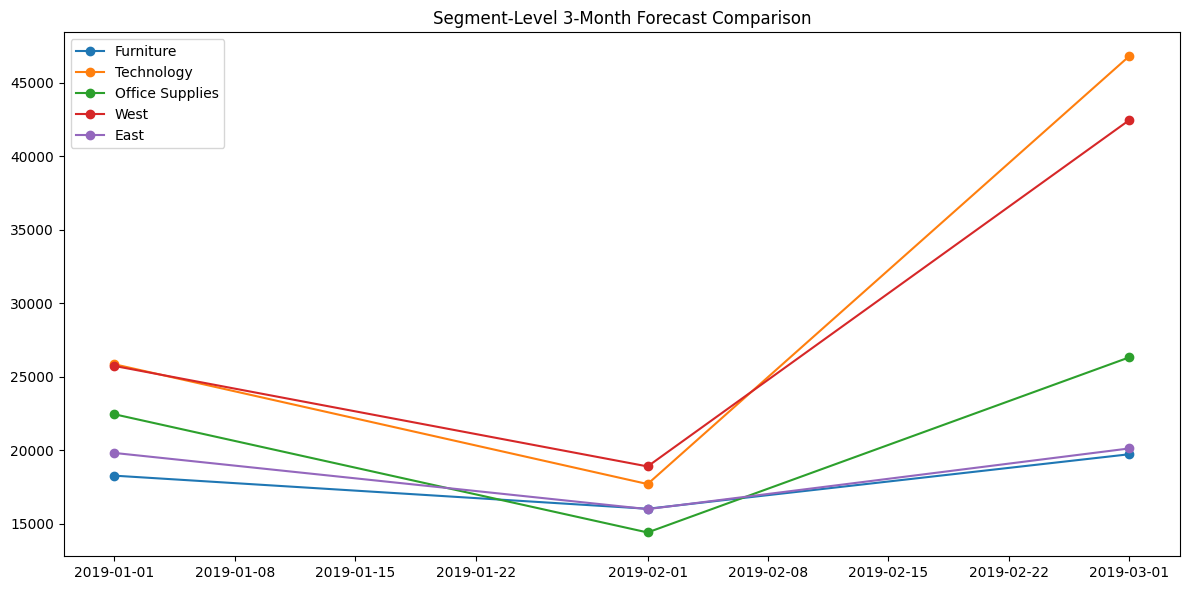

Technology         81.154922
West               65.028426
Office Supplies    17.254770
Furniture           7.980372
East                1.545335
dtype: float64
           Segment           MAE          RMSE  Forecast_Month1  \
0        Furniture   2642.278490   3949.939038     18258.982564   
1       Technology  12181.725904  13754.979639     25840.213268   
2  Office Supplies   1369.843185   1522.320969     22439.195902   
3             West   9262.670411   9750.033209     25726.864184   
4             East  10312.800710  11995.678123     19805.177913   

   Forecast_Month2  Forecast_Month3  
0     16005.234606     19716.117331  
1     17688.138471     46810.818314  
2     14392.985401     26311.027534  
3     18887.446790     42456.639016  
4     15981.330821     20111.234270  


In [20]:
segments = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West": df[df["Region"] == "West"],
    "East": df[df["Region"] == "East"]
}

segment_results = {}
segment_forecasts = {}

for name, seg_df in segments.items():
    seg_daily = seg_df.groupby(seg_df["Order Date"].dt.date)["Sales"].sum()
    seg_daily.index = pd.to_datetime(seg_daily.index)
    seg_monthly = seg_daily.resample("MS").sum()

    seg_train_monthly = seg_monthly[:-3]
    seg_test_monthly = seg_monthly[-3:]
    cutoff = seg_monthly.index[-3]
    seg_train_daily = seg_daily[seg_daily.index < cutoff]

    eval_df = seg_train_daily.reset_index()
    eval_df.columns = ["ds", "y"]
    eval_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    eval_model.fit(eval_df)
    eval_future = eval_model.make_future_dataframe(periods=100)
    eval_forecast = eval_model.predict(eval_future).set_index("ds")["yhat"]
    eval_monthly = eval_forecast.resample("MS").sum().loc[seg_test_monthly.index]

    seg_mae = mean_absolute_error(seg_test_monthly, eval_monthly)
    seg_rmse = np.sqrt(mean_squared_error(seg_test_monthly, eval_monthly))

    full_df = seg_daily.reset_index()
    full_df.columns = ["ds", "y"]
    full_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    full_model.fit(full_df)
    full_future = full_model.make_future_dataframe(periods=100)
    full_forecast = full_model.predict(full_future).set_index("ds")["yhat"]
    full_monthly_forecast = full_forecast.resample("MS").sum()
    future_forecast = full_monthly_forecast[full_monthly_forecast.index > seg_monthly.index[-1]][:3]

    joblib.dump(full_model, os.path.join(MODEL_DIR, f"segment_{name.replace(' ', '_')}_model.pkl"))

    segment_forecasts[name] = future_forecast
    segment_results[name] = {
        "MAE": seg_mae,
        "RMSE": seg_rmse,
        "Forecast_Month1": future_forecast.iloc[0],
        "Forecast_Month2": future_forecast.iloc[1],
        "Forecast_Month3": future_forecast.iloc[2]
    }

plt.figure(figsize=(12,6))
for name, forecast in segment_forecasts.items():
    plt.plot(forecast.index, forecast.values, marker="o", label=name)
plt.legend()
plt.title("Segment-Level 3-Month Forecast Comparison")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "segment_forecast_comparison.png"))
plt.show()

growth_summary = {name: (f.iloc[-1] - f.iloc[0]) / f.iloc[0] * 100 for name, f in segment_forecasts.items()}
print(pd.Series(growth_summary).sort_values(ascending=False))

segment_metrics_df = pd.DataFrame(segment_results).T.reset_index().rename(columns={"index": "Segment"})
print(segment_metrics_df)
segment_metrics_df.to_csv(os.path.join(BASE_DIR, "segment_model_metrics.csv"), index=False)

Technology projects the highest increase over 3-month period (+81.2%), trailed by West (+65.0%). Office Supplies (+17.3%) and Furniture (+8.0%) increase at a moderate pace, with East (+1.5%) just about even. The other three contrast markedly with technology and west, which are the two areas that will most likely require stock builds in the coming years.

# **Anomaly Detection**

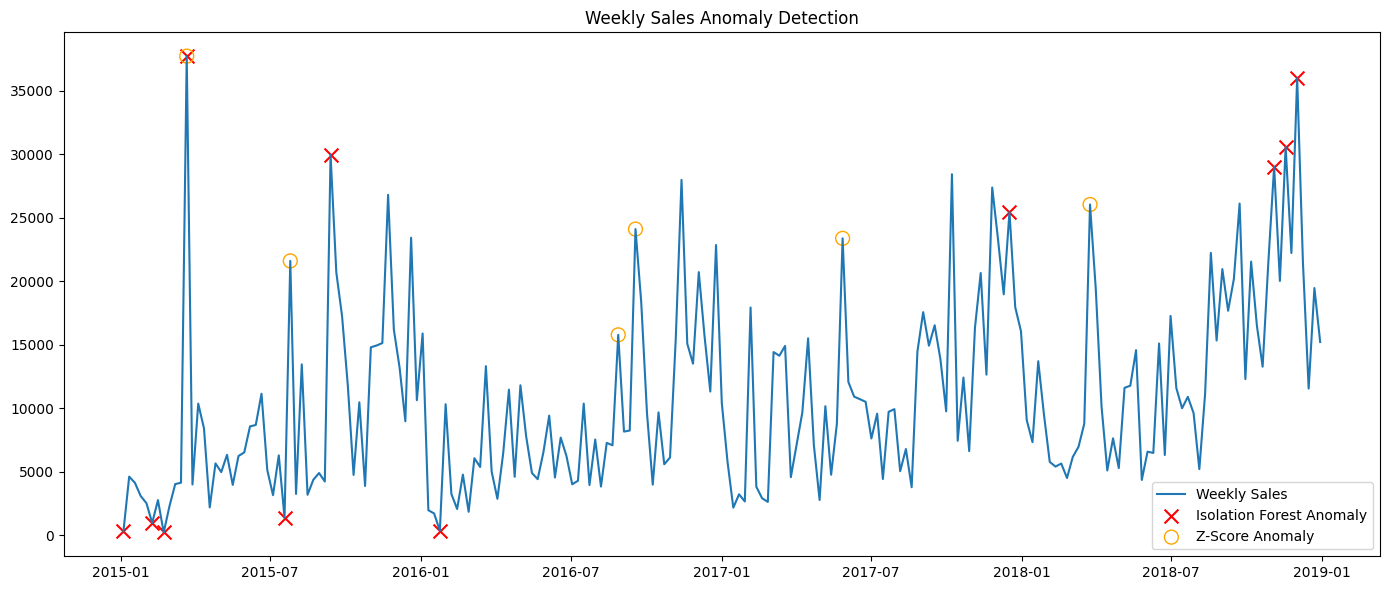

Flagged by both: 1
Isolation Forest only: 10
Z-score only: 5


In [21]:
anomaly_df = weekly_sales.reset_index()
anomaly_df.columns = ["Date", "Sales"]
anomaly_df["RollingMean"] = anomaly_df["Sales"].rolling(8).mean()
anomaly_df["RollingStd"] = anomaly_df["Sales"].rolling(8).std()

iso_features = anomaly_df[["Sales"]].bfill()
iso_model = IsolationForest(contamination=0.05, random_state=42)
anomaly_df["IsoAnomaly"] = iso_model.fit_predict(iso_features)
anomaly_df["IsoAnomaly"] = anomaly_df["IsoAnomaly"].map({1: 0, -1: 1})

anomaly_df["ZScore"] = (anomaly_df["Sales"] - anomaly_df["RollingMean"]) / anomaly_df["RollingStd"]
anomaly_df["ZAnomaly"] = (anomaly_df["ZScore"].abs() > 2).astype(int)

plt.figure(figsize=(14,6))
plt.plot(anomaly_df["Date"], anomaly_df["Sales"], label="Weekly Sales")
iso_points = anomaly_df[anomaly_df["IsoAnomaly"] == 1]
z_points = anomaly_df[anomaly_df["ZAnomaly"] == 1]
plt.scatter(iso_points["Date"], iso_points["Sales"], color="red", marker="x", s=100, label="Isolation Forest Anomaly")
plt.scatter(z_points["Date"], z_points["Sales"], facecolors="none", edgecolors="orange", s=100, label="Z-Score Anomaly")
plt.legend()
plt.title("Weekly Sales Anomaly Detection")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "anomaly_detection.png"))
plt.show()

agreement = anomaly_df[(anomaly_df["IsoAnomaly"] == 1) & (anomaly_df["ZAnomaly"] == 1)]
iso_only = anomaly_df[(anomaly_df["IsoAnomaly"] == 1) & (anomaly_df["ZAnomaly"] == 0)]
z_only = anomaly_df[(anomaly_df["IsoAnomaly"] == 0) & (anomaly_df["ZAnomaly"] == 1)]

print("Flagged by both:", len(agreement))
print("Isolation Forest only:", len(iso_only))
print("Z-score only:", len(z_only))

joblib.dump(iso_model, os.path.join(MODEL_DIR, "isolation_forest_model.pkl"))
anomaly_df.to_csv(os.path.join(BASE_DIR, "anomaly_report.csv"), index=False)

In [22]:
print(anomaly_df[anomaly_df["IsoAnomaly"] == 1][["Date", "Sales"]])

          Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


Isolation Forest and Z-score have only 1 in 16 flagged weeks in common. The biggest sales weeks in the data set are those with the largest absolute sales dimension across the entire data set, regardless of local context (about 37k and 30k weeks in 2015). Z score flags weeks that are atypical when compared to the recent 8-week window (mid-2016, late-2016, mid-2018), for which they were calculated – even if these weeks themselves are not unusually large in absolute terms. This gives us insight into the fact that the two methods are detecting different types of "unusual": Isolation Forest - overall extremes; Z Score - local, context-dependent deviations. They're both correct options, but each answers a different business question.

Top 3 anomalies:
1. March 22, 2015 (37,703) -- largest single week in the dataset. This is a single day of holiday, and is separated from a nearby spike, so probably not a seasonal order, but rather a bulk/enterprise order.
2. December 2, 2018 (35,999) -- second biggest week after the confirmed November-December seasonal peak (heatmap shows November 2018 is the highest month in the dataset, 117,938). This is explainable because of the seasonality.
3.  September 13, 2015 (29,959) -- 3rd largest week with no seasonal or holiday explanation, 13th September, 29,959.

Limitation: There are not all seasonality anomalies. This analysis does not explain why two of the three largest spikes (March 2015 and September 2015) are occurring: They require order-level investigation (sales rep records, bulk order logs), which is not possible with just the weekly numbers. The anomalies (weeks that were quite low) bunch up in 2015-early 2016, which is more consistent with the ramp-up of the early datasets than with any other pattern, but this is a suggestion and not substantiated by outside business circumstances.

# **Product Demand Segmentation**

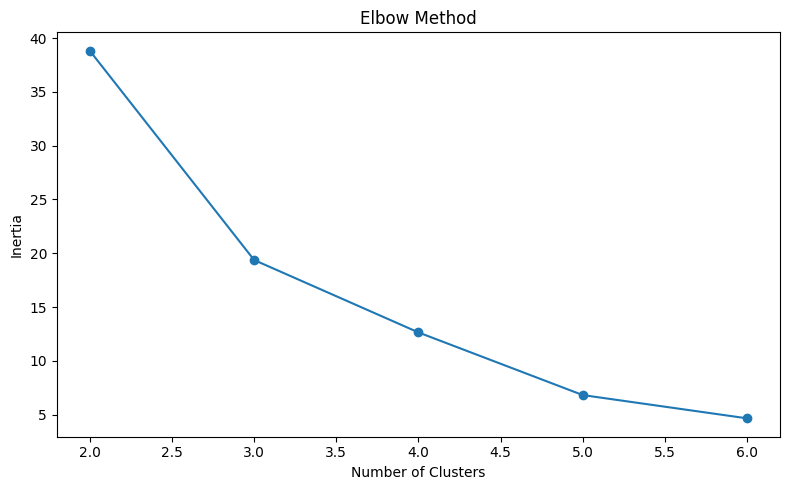

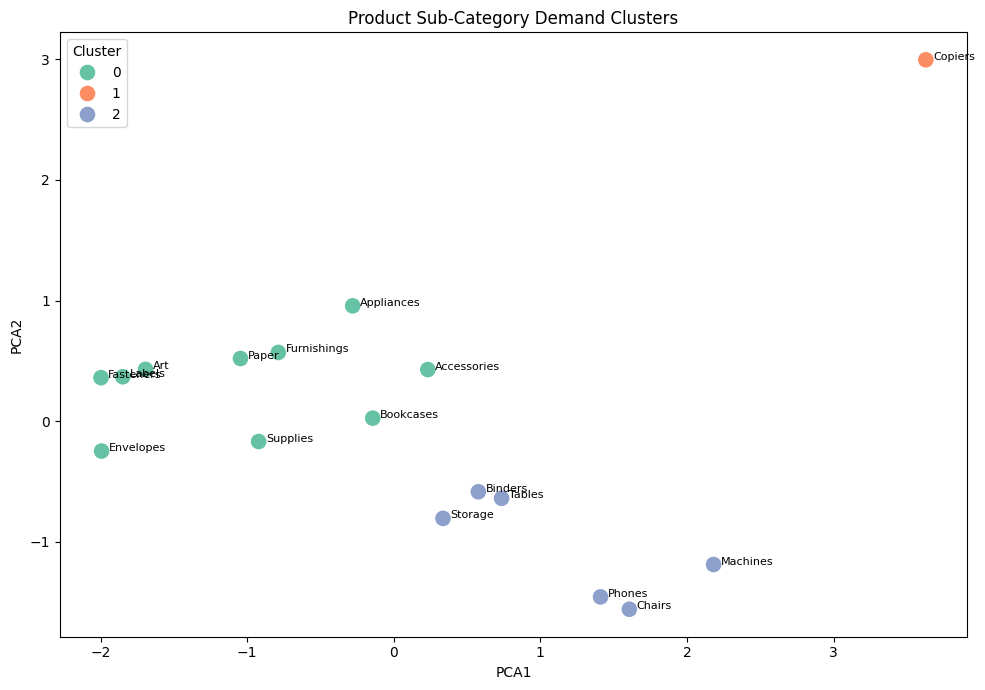

   Sub-Category   TotalSales  GrowthRate   Volatility  AvgOrderValue  Cluster
0   Accessories  164186.7000    0.348202  2579.994809     217.178175        0
1    Appliances  104618.4030    0.384250  1821.621539     227.926804        0
2           Art   26705.4100    0.143822   330.488343      34.019631        0
3       Binders  200028.7850    0.183522  3848.223648     134.067550        2
4     Bookcases  113813.1987    0.144324  2220.405080     503.598224        0
5        Chairs  322822.7310    0.065469  4407.232960     531.833165        2
6       Copiers  146248.0940    0.796422  5500.774391    2215.880212        1
7     Envelopes   16128.0460   -0.042157   228.218688      65.032444        0
8     Fasteners    3001.9600    0.092702    48.742229      14.027850        0
9   Furnishings   89212.0180    0.274093  1360.017867      95.823865        0
10       Labels   12347.7260    0.108131   223.471218      34.587468        0
11     Machines  189238.6310   -0.111222  5603.554747    1645.55

In [23]:
subcat_features = df.groupby("Sub-Category").agg(
    TotalSales=("Sales", "sum"),
    AvgOrderValue=("Sales", "mean")
).reset_index()

subcat_yearly = df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack()

first_year = subcat_yearly.iloc[:, 0]
last_year = subcat_yearly.iloc[:, -1]
years_span = subcat_yearly.shape[1] - 1
subcat_growth = (last_year / first_year) ** (1 / years_span) - 1

subcat_monthly = df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="MS")])["Sales"].sum().unstack()
subcat_volatility = subcat_monthly.std(axis=1)

subcat_features["GrowthRate"] = subcat_features["Sub-Category"].map(subcat_growth)
subcat_features["Volatility"] = subcat_features["Sub-Category"].map(subcat_volatility)
subcat_features = subcat_features.dropna()

cluster_cols = ["TotalSales", "GrowthRate", "Volatility", "AvgOrderValue"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(subcat_features[cluster_cols])

inertia = []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "elbow_method.png"))
plt.show()

optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_features["Cluster"] = kmeans_model.fit_predict(scaled_features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
subcat_features["PCA1"] = pca_features[:,0]
subcat_features["PCA2"] = pca_features[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(data=subcat_features, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=150)
for _, row in subcat_features.iterrows():
    plt.text(row["PCA1"] + 0.05, row["PCA2"], row["Sub-Category"], fontsize=8)
plt.title("Product Sub-Category Demand Clusters")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "cluster_scatter.png"))
plt.show()

print(subcat_features[["Sub-Category", "TotalSales", "GrowthRate", "Volatility", "AvgOrderValue", "Cluster"]])

joblib.dump(kmeans_model, os.path.join(MODEL_DIR, "kmeans_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(pca, os.path.join(MODEL_DIR, "pca_model.pkl"))
subcat_features.to_csv(os.path.join(BASE_DIR, "cluster_assignments.csv"), index=False)

Cluster 0 (Accessories, Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies) -- Stable Core Demand. Moderate to moderate-high volume, moderate growth, low to moderate volatility. Constant reorder point inventory system, with no special buffer required.

Cluster1 (Copiers only): Niche High Value, High Growth. The highest growth rate (79.6%) and highest average order value (2,215.88) among all sub-categories and was the only category that could be identified in all clustering tests (k=3 to k=6). Stocking strategy: low unit volume high per unit value – focus on availability rather than quantity of stock, but may consider pre-order/made to order, due to high per-unit value.

Cluster 2 (Binders, Chairs, Machines, Phones, Storage, Tables) – High Value, Variable Demand. The volatility and order values are greater than Cluster 0. Here, the real multi-year decline is for Machines (-11.1% from 62k to 28k to 56k to 44k, 2015 to 2018), rather than a data artifact, and that is what is causing the negative growth. Safety stock: keep safety stock for fluctuations in demand, but for Machines, the reorder target would be lowered due to the downward trend and the assumption of cluster should not be used on it.

# **Cluster Validation**

In [24]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

for k, s in zip(k_range, silhouette_scores):
    print(k, s)

2 0.38301447320301174
3 0.4295007074760417
4 0.39764588933916606
5 0.3821909541521274
6 0.3918297161850023


In [25]:
print(df[df["Sub-Category"] == "Machines"].groupby("Year")["Sales"].sum())

Year
2015    62023.373
2016    27763.697
2017    55906.886
2018    43544.675
Name: Sales, dtype: float64


In [26]:
print(subcat_features.groupby("Cluster")[["TotalSales", "GrowthRate", "Volatility", "AvgOrderValue"]].mean())

           TotalSales  GrowthRate   Volatility  AvgOrderValue
Cluster                                                      
0         65326.20737    0.173231  1186.287889     150.189900
1        146248.09400    0.796422  5500.774391    2215.880212
2        243671.10250    0.076460  3992.982732     599.193752


In [27]:
print(subcat_features.groupby("Cluster")[["TotalSales", "GrowthRate", "Volatility", "AvgOrderValue"]].std())

           TotalSales  GrowthRate  Volatility  AvgOrderValue
Cluster                                                     
0        53052.993995    0.136511  945.552750     152.775938
1                 NaN         NaN         NaN            NaN
2        63982.279486    0.099708  974.913295     544.272040


Cluster validation was necessary because K-Means on 17 sub-categories is small-sample clustering, and the elbow method alone was misleading: at k=4, both the original and corrected GrowthRate features produced a cluster with exactly one member (Supplies, then Machines), and inertia does not penalize this — a singleton always minimizes inertia locally, so the elbow curve looked fine even when the grouping was degenerate.

Silhouette score was added to check cluster cohesion, not just inertia reduction. When GrowthRate was recalculated from an average of year-over-year percent changes to CAGR (since Supplies' original 192.8% figure was an artifact of one bad year in 2016), the best silhouette score shifted from k=4 to k=3 — showing that fixing one feature changes which k is actually optimal, not just the cluster labels within a fixed k.

Cluster mean and standard deviation were checked next: k=3 removed one singleton (Supplies merged into Cluster 0), but that cluster's spread was still high, with AvgOrderValue's standard deviation nearly equal to its mean. It was broad but not incoherent enough to justify forcing a 4th cluster just for a marginal inertia drop.

This validation distinguishes a real outlier (Copiers — isolated in every clustering run from k=3 to k=6, with the highest growth rate and highest average order value by a wide margin) from a computational artifact (Supplies' inflated growth rate, traced to one low-sales year and corrected before finalizing the clustering).

# **Zip Models and Visuals**

In [28]:
def zip_directory(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)
                zf.write(file_path, arcname)

zip_directory(MODEL_DIR, os.path.join(BASE_DIR, "models.zip"))
zip_directory(VIS_DIR, os.path.join(BASE_DIR, "visuals.zip"))

print("models.zip and visuals.zip created in /kaggle/working")

models.zip and visuals.zip created in /kaggle/working
